--- Linear Regression Performance ---
MAE: 0.835
RMSE: 1.082
R2 Score: 0.970

--- Random Forest Regressor Performance ---
MAE: 0.928
RMSE: 1.186
R2 Score: 0.964



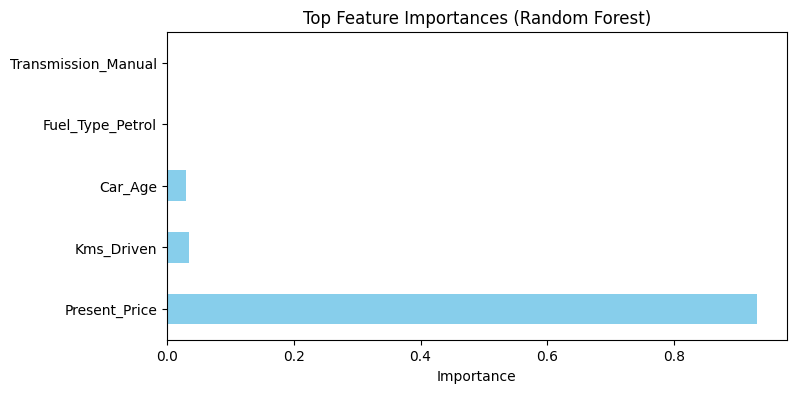

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset Generation (Synthetic Car Dataset for instant execution)
np.random.seed(42)
n_samples = 300

present_price = np.random.uniform(3.0, 35.0, n_samples)
car_age = np.random.randint(1, 15, n_samples)
kms_driven = np.random.randint(5000, 150000, n_samples)
fuel_type = np.random.choice(['Petrol', 'Diesel', 'CNG'], n_samples)
transmission = np.random.choice(['Manual', 'Automatic'], n_samples)

# Formula to simulate realistic selling price
selling_price = (present_price * 0.75) - (car_age * 0.4) - (kms_driven / 30000) + np.random.normal(0, 1, n_samples)
selling_price = np.maximum(0.5, selling_price) # Minimum price safety check

df = pd.DataFrame({
    'Selling_Price': selling_price,
    'Present_Price': present_price,
    'Kms_Driven': kms_driven,
    'Fuel_Type': fuel_type,
    'Transmission': transmission,
    'Car_Age': car_age
})

# 2. Preprocessing & Encoding
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Transmission'], drop_first=True)

X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 5. Evaluation Function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2 Score: {r2:.3f}\n")

evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest Regressor", y_test, rf_preds)

# 6. Feature Importance Visualization
plt.figure(figsize=(8, 4))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

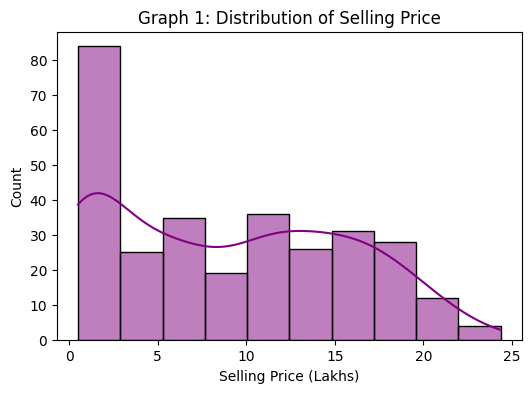

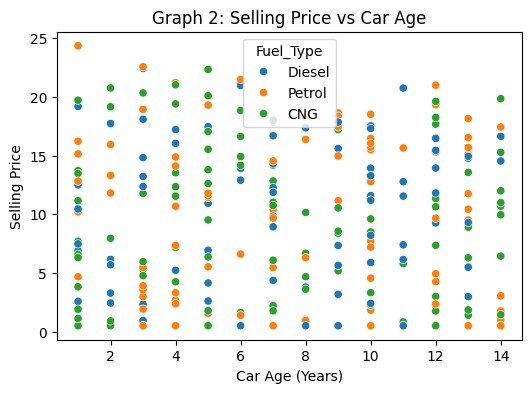

/tmp/ipykernel_3432/1885963030.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')


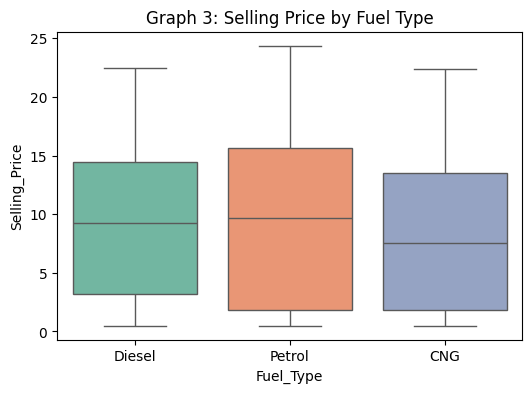

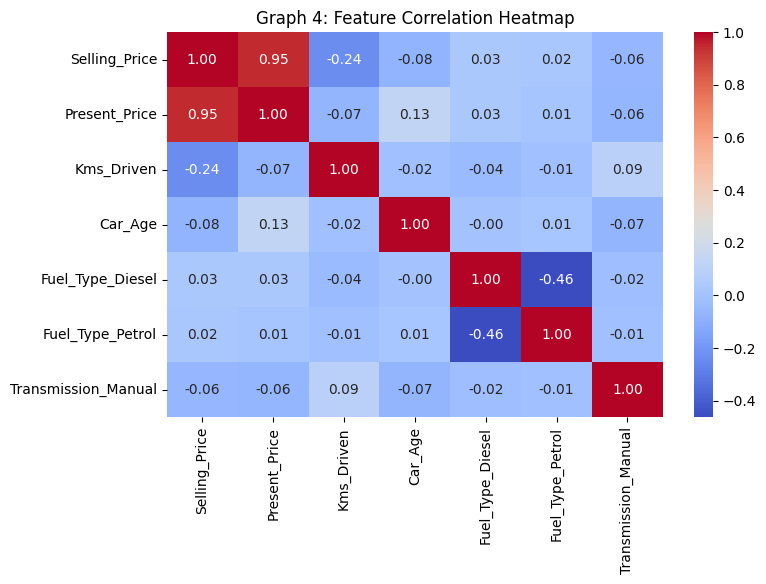

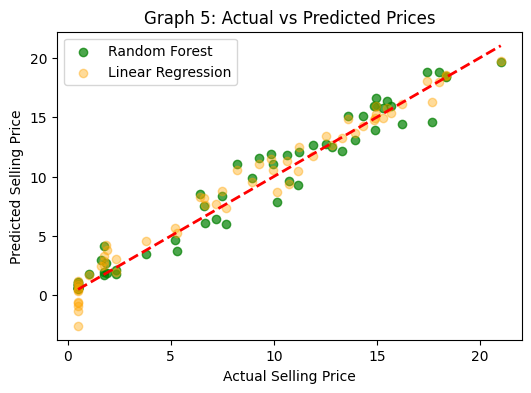

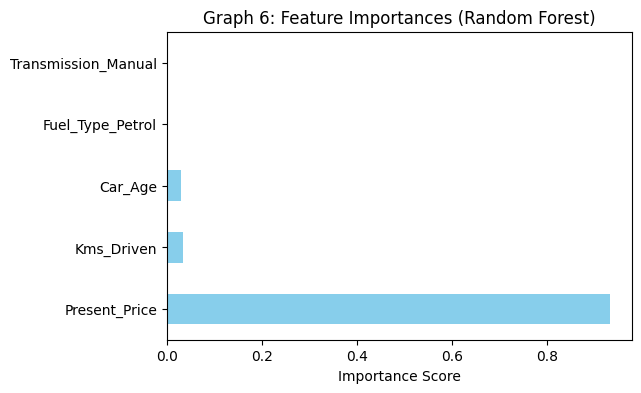

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset Generation
np.random.seed(42)
n_samples = 300

present_price = np.random.uniform(3.0, 35.0, n_samples)
car_age = np.random.randint(1, 15, n_samples)
kms_driven = np.random.randint(5000, 150000, n_samples)
fuel_type = np.random.choice(['Petrol', 'Diesel', 'CNG'], n_samples)
transmission = np.random.choice(['Manual', 'Automatic'], n_samples)

selling_price = (present_price * 0.75) - (car_age * 0.4) - (kms_driven / 30000) + np.random.normal(0, 1, n_samples)
selling_price = np.maximum(0.5, selling_price)

df = pd.DataFrame({
    'Selling_Price': selling_price,
    'Present_Price': present_price,
    'Kms_Driven': kms_driven,
    'Fuel_Type': fuel_type,
    'Transmission': transmission,
    'Car_Age': car_age
})

# --- GRAPH 1: Distribution of Target Variable (Selling Price) ---
plt.figure(figsize=(6, 4))
sns.histplot(df['Selling_Price'], kde=True, color='purple')
plt.title('Graph 1: Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.show()

# --- GRAPH 2: Scatter Plot (Price vs Car Age) ---
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, hue='Fuel_Type')
plt.title('Graph 2: Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

# --- GRAPH 3: Box Plot (Price vs Fuel Type) ---
plt.figure(figsize=(6, 4))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Graph 3: Selling Price by Fuel Type')
plt.show()

# Preprocessing & Correlation
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Transmission'], drop_first=True)

# --- GRAPH 4: Correlation Heatmap ---
plt.figure(figsize=(8, 5))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Graph 4: Feature Correlation Heatmap')
plt.show()

# Model Training
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression().fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- GRAPH 5: Actual vs Predicted Prices ---
plt.figure(figsize=(6, 4))
plt.scatter(y_test, rf_preds, alpha=0.7, color='green', label='Random Forest')
plt.scatter(y_test, lr_preds, alpha=0.4, color='orange', label='Linear Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Graph 5: Actual vs Predicted Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.legend()
plt.show()

# --- GRAPH 6: Feature Importances ---
plt.figure(figsize=(6, 4))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Graph 6: Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()